# 参数曲线、隐函数、参数曲面与隐式曲面

这个 notebook 用 Python 图形展示四类对象：

1. 二维参数曲线：$\mathbf r(t)=(x(t),y(t))$。
2. 二维隐式曲线：$F(x,y)=0$。
3. 三维参数曲面：$\mathbf r(u,v)=(x(u,v),y(u,v),z(u,v))$。
4. 三维隐式曲面：$F(x,y,z)=0$。

核心思想是：**参数形式适合生成点和运动轨迹，隐式形式适合描述水平集、内外区域和法向量。**


## 0. 环境检查与导入

如果下面单元提示缺少依赖，请在终端运行：

```bash
python3 -m pip install -r requirements.txt
jupyter lab parametric_implicit_geometry_visuals.ipynb
```

隐式曲面使用 `scikit-image` 的 `marching_cubes` 从三维体数据中提取等值面。

In [1]:
# 导入 importlib.util，用于在真正 import 前检查包是否安装。
import importlib.util
# 导入 os，用于设置 Matplotlib 缓存目录等环境变量。
import os
# 导入 sys，用于显示当前 Python 版本。
import sys

# 在部分受限环境中，Matplotlib 默认配置目录可能不可写；这里指定到 /tmp。
os.environ.setdefault("MPLCONFIGDIR", "/tmp/matplotlib")

# 本 notebook 需要的依赖包。
required_packages = ["numpy", "matplotlib", "plotly", "ipywidgets", "scipy", "skimage"]
# 找出当前 Python 环境中缺失的依赖。
missing_packages = [name for name in required_packages if importlib.util.find_spec(name) is None]

# 打印 Python 版本，帮助确认 kernel 环境。
print(f"Python: {sys.version.split()[0]}")
# 如果依赖缺失，给出安装命令并停止执行。
if missing_packages:
    print("缺少依赖：" + ", ".join(missing_packages))
    print("请先运行：python3 -m pip install -r requirements.txt")
    raise ModuleNotFoundError("Missing packages: " + ", ".join(missing_packages))

# NumPy 负责数组、网格、向量化计算和线性代数。
import numpy as np
# Matplotlib 负责二维静态图，例如曲线、等高线和向量场。
import matplotlib.pyplot as plt
# Matplotlib 字体管理器用于检测中文字体。
from matplotlib import font_manager
# Plotly graph_objects 负责三维交互图。
import plotly.graph_objects as go
# ipywidgets 提供 Jupyter 中的滑块交互。
from ipywidgets import FloatSlider, interact
# marching_cubes 用于从 F(x,y,z)=level 的体数据中提取三角网格。
from skimage.measure import marching_cubes

# 常见中文字体候选；不同系统能识别到的名称不同。
chinese_font_candidates = [
    "Noto Sans CJK SC",
    "Noto Sans CJK JP",
    "Noto Sans CJK TC",
    "Source Han Sans SC",
    "Source Han Sans CN",
    "WenQuanYi Micro Hei",
    "Microsoft YaHei",
    "SimHei",
    "Arial Unicode MS",
]
# 读取 Matplotlib 当前字体缓存中的字体名称。
available_font_names = {font.name for font in font_manager.fontManager.ttflist}
# 选择第一个可用中文字体。
matplotlib_chinese_font = next((name for name in chinese_font_candidates if name in available_font_names), None)

# 设置 Matplotlib 的默认图形尺寸。
plt.rcParams["figure.figsize"] = (7, 5)
# 设置字体族。
plt.rcParams["font.family"] = "sans-serif"
# 如果找到中文字体，就优先使用它。
if matplotlib_chinese_font:
    plt.rcParams["font.sans-serif"] = [matplotlib_chinese_font, "DejaVu Sans"]
# 如果没有找到，仍写入候选列表，用户安装字体后重启 kernel 即可生效。
else:
    plt.rcParams["font.sans-serif"] = chinese_font_candidates + ["DejaVu Sans"]
# 避免坐标轴负号显示为方框。
plt.rcParams["axes.unicode_minus"] = False

print("依赖检查通过。")
if matplotlib_chinese_font:
    print("Matplotlib 中文字体：" + matplotlib_chinese_font)
else:
    print("未检测到 Matplotlib 可用中文字体，二维图中的中文可能显示为方框。")
    print("解决方案 Linux/WSL: sudo apt update && sudo apt install fonts-noto-cjk")
    print("安装后重启 Jupyter kernel；如仍无效，可删除字体缓存：rm -rf ~/.cache/matplotlib")


Python: 3.13.5
依赖检查通过。
Matplotlib 中文字体：Noto Sans CJK JP


## 0.1 绘图环境与命令速查

- `np.linspace`：把连续区间离散成采样点。
- `np.meshgrid`：把一维坐标轴扩展成二维或三维网格。
- `ax.plot` / `ax.contour` / `ax.quiver`：画二维曲线、隐式曲线和向量场。
- `go.Scatter3d` / `go.Surface` / `go.Mesh3d`：画三维曲线、参数曲面和隐式曲面。
- `marching_cubes`：把三维标量场 $F(x,y,z)$ 的等值面提取成三角网格。
- `interact` + `FloatSlider`：让参数变化和重新绘图绑定起来。

## 1. 通用绘图工具

这些函数把绘图细节封装起来，后续示例主要关注数学对象本身。

In [2]:
# 生成二维网格；用于隐式曲线和二维背景计算。
def make_2d_grid(xlim=(-3, 3), ylim=(-3, 3), n=401):
    """返回 x, y, X, Y，其中 X,Y 是二维网格。"""
    # 在 x 方向生成 n 个采样点。
    x = np.linspace(xlim[0], xlim[1], n)
    # 在 y 方向生成 n 个采样点。
    y = np.linspace(ylim[0], ylim[1], n)
    # 生成二维网格坐标矩阵。
    X, Y = np.meshgrid(x, y)
    # 同时返回一维坐标轴和二维网格。
    return x, y, X, Y


# 生成三维网格；用于隐式曲面 F(x,y,z)=level 的数值采样。
def make_3d_grid(xlim=(-2, 2), ylim=(-2, 2), zlim=(-2, 2), n=64):
    """返回 x, y, z, X, Y, Z，其中 X,Y,Z 是三维网格。"""
    # 在三个方向分别生成采样点。
    x = np.linspace(xlim[0], xlim[1], n)
    y = np.linspace(ylim[0], ylim[1], n)
    z = np.linspace(zlim[0], zlim[1], n)
    # indexing='ij' 让数组轴顺序对应 x,y,z，便于 marching_cubes spacing 对齐。
    X, Y, Z = np.meshgrid(x, y, z, indexing="ij")
    return x, y, z, X, Y, Z


# 数值计算二维隐式函数的梯度。
def numerical_gradient_2d(F, x, y, h=1e-5):
    """用中心差分近似 ∇F(x,y)。"""
    Fx = (F(x + h, y) - F(x - h, y)) / (2 * h)
    Fy = (F(x, y + h) - F(x, y - h)) / (2 * h)
    return Fx, Fy


# 数值计算三维隐式函数的梯度。
def numerical_gradient_3d(F, x, y, z, h=1e-5):
    """用中心差分近似 ∇F(x,y,z)。"""
    Fx = (F(x + h, y, z) - F(x - h, y, z)) / (2 * h)
    Fy = (F(x, y + h, z) - F(x, y - h, z)) / (2 * h)
    Fz = (F(x, y, z + h) - F(x, y, z - h)) / (2 * h)
    return Fx, Fy, Fz


# 归一化向量，避免重复写除以长度的逻辑。
def normalize_vector(v, eps=1e-12):
    """返回单位向量；如果长度接近 0，返回原向量。"""
    v = np.asarray(v, dtype=float)
    norm = np.linalg.norm(v)
    if norm < eps:
        return v
    return v / norm


# 在 Plotly 三维图里添加一条向量线段。
def add_3d_vector(fig, origin, vector, name="vector", color="crimson", scale=1.0):
    """向已有 Plotly figure 添加从 origin 出发的三维向量。"""
    origin = np.asarray(origin, dtype=float)
    vector = np.asarray(vector, dtype=float) * scale
    end = origin + vector
    fig.add_trace(
        go.Scatter3d(
            x=[origin[0], end[0]],
            y=[origin[1], end[1]],
            z=[origin[2], end[2]],
            mode="lines+markers",
            line={"color": color, "width": 7},
            marker={"size": 4, "color": color},
            name=name,
        )
    )


# 绘制二维参数曲线，并可在指定参数处显示切向量。
def plot_parametric_curve(x, y, t, tangent_at=None, title="", equal_aspect=True):
    """绘制 r(t)=(x(t),y(t))，并可显示若干 t0 处的切向量。"""
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    t = np.asarray(t, dtype=float)
    dx_dt = np.gradient(x, t)
    dy_dt = np.gradient(y, t)

    fig, ax = plt.subplots(figsize=(7.2, 6.2))
    ax.plot(x, y, color="royalblue", linewidth=2.4, label="参数曲线")
    ax.scatter([x[0]], [y[0]], color="green", s=45, label="起点", zorder=4)
    ax.scatter([x[-1]], [y[-1]], color="black", s=45, label="终点", zorder=4)

    if tangent_at is not None:
        tangent_values = np.atleast_1d(tangent_at)
        span = max(np.ptp(x), np.ptp(y), 1.0)
        arrow_scale = 0.16 * span
        for t0 in tangent_values:
            idx = int(np.argmin(np.abs(t - t0)))
            tangent = normalize_vector([dx_dt[idx], dy_dt[idx]]) * arrow_scale
            ax.quiver(
                [x[idx]],
                [y[idx]],
                [tangent[0]],
                [tangent[1]],
                angles="xy",
                scale_units="xy",
                scale=1,
                color="crimson",
                width=0.008,
                label="切向量" if t0 == tangent_values[0] else None,
            )
            ax.annotate(f"t={t[idx]:.2f}", (x[idx], y[idx]), xytext=(7, 7), textcoords="offset points")

    ax.set_title(title)
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    if equal_aspect:
        ax.set_aspect("equal", adjustable="box")
    ax.grid(alpha=0.25)
    ax.legend(loc="best")
    plt.show()


# 绘制二维隐式曲线 F(x,y)=level，并可显示梯度法向量。
def plot_implicit_curve(F, xlim=(-3, 3), ylim=(-3, 3), level=0.0, n=401, grad_F=None, points=None, title=""):
    """绘制隐式曲线 F(x,y)=level；∇F 是曲线的法向量。"""
    _, _, X, Y = make_2d_grid(xlim, ylim, n)
    Z = np.asarray(F(X, Y), dtype=float)

    fig, ax = plt.subplots(figsize=(7.2, 6.2))
    background_levels = np.linspace(np.nanmin(Z), np.nanmax(Z), 18)
    ax.contour(X, Y, Z, levels=background_levels, cmap="Greys", alpha=0.45, linewidths=0.7)
    contour = ax.contour(X, Y, Z, levels=[level], colors="crimson", linewidths=2.5)
    ax.clabel(contour, fmt={level: f"F={level:g}"}, inline=True, fontsize=9)

    if points:
        span = max(xlim[1] - xlim[0], ylim[1] - ylim[0])
        arrow_scale = 0.10 * span
        for k, (px, py) in enumerate(points):
            gx, gy = grad_F(px, py) if grad_F else numerical_gradient_2d(F, px, py)
            normal = normalize_vector([gx, gy]) * arrow_scale
            tangent = normalize_vector([-gy, gx]) * arrow_scale
            ax.scatter([px], [py], c="black", s=45, zorder=5)
            ax.quiver([px], [py], [normal[0]], [normal[1]], angles="xy", scale_units="xy", scale=1, color="crimson", width=0.008, label="法向 ∇F" if k == 0 else None)
            ax.quiver([px], [py], [tangent[0]], [tangent[1]], angles="xy", scale_units="xy", scale=1, color="royalblue", width=0.008, label="切向" if k == 0 else None)
            ax.annotate(f"({px:.2f},{py:.2f})", (px, py), xytext=(7, 7), textcoords="offset points")

    ax.set_title(title)
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_aspect("equal", adjustable="box")
    ax.grid(alpha=0.2)
    if points:
        ax.legend(loc="best")
    plt.show()


# 绘制三维参数曲面，并可显示局部切向量和法向量。
def plot_parametric_surface(X, Y, Z, u=None, v=None, sample_uv=None, title="", colorscale="Viridis"):
    """绘制参数曲面 r(u,v)，并可在 sample_uv 处显示 r_u、r_v 和法向量。"""
    fig = go.Figure()
    fig.add_trace(
        go.Surface(
            x=X,
            y=Y,
            z=Z,
            colorscale=colorscale,
            opacity=0.92,
            colorbar={"title": "参数"},
            name="参数曲面",
        )
    )

    if sample_uv is not None and u is not None and v is not None:
        u0, v0 = sample_uv
        i = int(np.argmin(np.abs(np.asarray(u) - u0)))
        j = int(np.argmin(np.abs(np.asarray(v) - v0)))
        dX_du, dX_dv = np.gradient(X, u, v, edge_order=2)
        dY_du, dY_dv = np.gradient(Y, u, v, edge_order=2)
        dZ_du, dZ_dv = np.gradient(Z, u, v, edge_order=2)
        ru = np.array([dX_du[i, j], dY_du[i, j], dZ_du[i, j]])
        rv = np.array([dX_dv[i, j], dY_dv[i, j], dZ_dv[i, j]])
        normal = np.cross(ru, rv)
        origin = np.array([X[i, j], Y[i, j], Z[i, j]])
        scale = 0.45
        add_3d_vector(fig, origin, normalize_vector(ru), name="r_u 切向", color="crimson", scale=scale)
        add_3d_vector(fig, origin, normalize_vector(rv), name="r_v 切向", color="royalblue", scale=scale)
        add_3d_vector(fig, origin, normalize_vector(normal), name="r_u × r_v 法向", color="black", scale=scale)

    fig.update_layout(title=title, width=900, height=650, margin={"l": 0, "r": 0, "t": 55, "b": 0})
    fig.update_scenes(xaxis_title="x", yaxis_title="y", zaxis_title="z", aspectmode="data")
    fig.show()
    return fig


# 绘制三维隐式曲面 F(x,y,z)=level。
def plot_implicit_surface(F, xlim=(-2, 2), ylim=(-2, 2), zlim=(-2, 2), level=0.0, n=64, grad_F=None, normal_point=None, title=""):
    """用 marching cubes 提取并绘制隐式曲面 F(x,y,z)=level。"""
    x, y, z, X, Y, Z = make_3d_grid(xlim, ylim, zlim, n)
    values = np.asarray(F(X, Y, Z), dtype=float)
    vmin, vmax = float(np.nanmin(values)), float(np.nanmax(values))
    if not (vmin <= level <= vmax):
        raise ValueError(f"level={level} 不在采样值范围 [{vmin:.3g}, {vmax:.3g}] 内，请调整范围或 level。")

    dx = (xlim[1] - xlim[0]) / (n - 1)
    dy = (ylim[1] - ylim[0]) / (n - 1)
    dz = (zlim[1] - zlim[0]) / (n - 1)
    vertices, faces, _, _ = marching_cubes(values, level=level, spacing=(dx, dy, dz))
    vertices += np.array([xlim[0], ylim[0], zlim[0]])

    fig = go.Figure(
        data=[
            go.Mesh3d(
                x=vertices[:, 0],
                y=vertices[:, 1],
                z=vertices[:, 2],
                i=faces[:, 0],
                j=faces[:, 1],
                k=faces[:, 2],
                color="steelblue",
                opacity=0.62,
                flatshading=False,
                lighting={"ambient": 0.55, "diffuse": 0.75, "specular": 0.25},
                name="隐式曲面",
            )
        ]
    )

    if normal_point is not None:
        px, py, pz = normal_point
        gx, gy, gz = grad_F(px, py, pz) if grad_F else numerical_gradient_3d(F, px, py, pz)
        add_3d_vector(fig, [px, py, pz], normalize_vector([gx, gy, gz]), name="法向 ∇F", color="crimson", scale=0.55)

    fig.update_layout(title=title, width=900, height=650, margin={"l": 0, "r": 0, "t": 55, "b": 0})
    fig.update_scenes(xaxis_title="x", yaxis_title="y", zaxis_title="z", aspectmode="data")
    fig.show()
    print(f"marching_cubes: {len(vertices)} 个顶点，{len(faces)} 个三角形。")
    return fig, vertices, faces


## 2. 参数曲线：用一个参数生成平面轨迹

参数曲线写作

$$\mathbf r(t)=(x(t),y(t)).$$

当 $t$ 变化时，点 $\mathbf r(t)$ 在平面上运动。速度向量

$$\mathbf r'(t)=(x'(t),y'(t))$$

给出曲线在该点的切向方向。

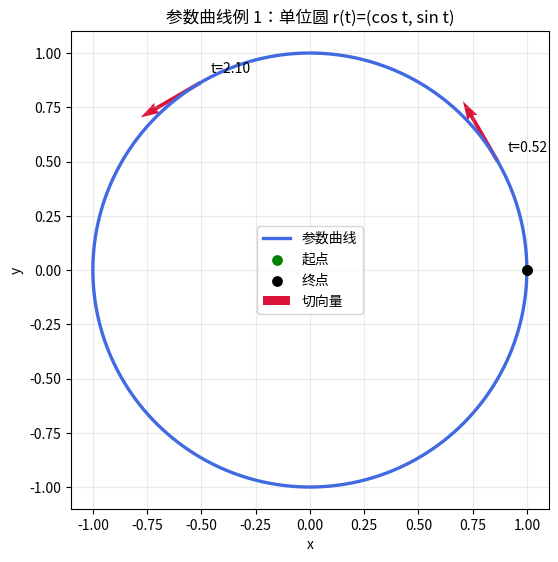

In [3]:
t = np.linspace(0, 2 * np.pi, 600)
x_circle = np.cos(t)
y_circle = np.sin(t)

plot_parametric_curve(
    x_circle,
    y_circle,
    t,
    tangent_at=[np.pi / 6, 2 * np.pi / 3],
    title="参数曲线例 1：单位圆 r(t)=(cos t, sin t)",
)


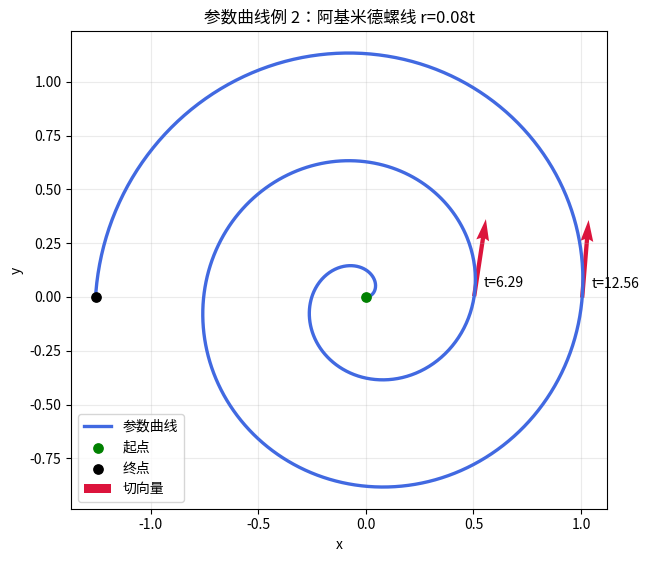

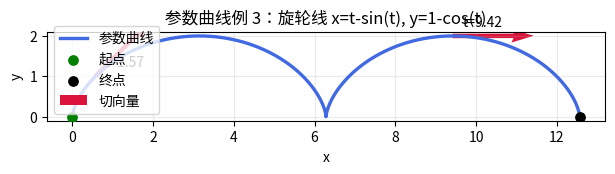

In [4]:
t_spiral = np.linspace(0, 5 * np.pi, 900)
r = 0.08 * t_spiral
x_spiral = r * np.cos(t_spiral)
y_spiral = r * np.sin(t_spiral)

plot_parametric_curve(
    x_spiral,
    y_spiral,
    t_spiral,
    tangent_at=[2 * np.pi, 4 * np.pi],
    title="参数曲线例 2：阿基米德螺线 r=0.08t",
)


t_cycloid = np.linspace(0, 4 * np.pi, 900)
x_cycloid = t_cycloid - np.sin(t_cycloid)
y_cycloid = 1 - np.cos(t_cycloid)

plot_parametric_curve(
    x_cycloid,
    y_cycloid,
    t_cycloid,
    tangent_at=[np.pi / 2, 3 * np.pi],
    title="参数曲线例 3：旋轮线 x=t-sin(t), y=1-cos(t)",
    equal_aspect=True,
)


## 3. 隐式曲线：平面上的水平集

隐式曲线写作

$$F(x,y)=0.$$

它不是直接告诉我们点如何运动，而是描述所有满足方程的点。若 $\nabla F(x_0,y_0)\neq 0$，则 $\nabla F$ 垂直于该点附近的隐式曲线。

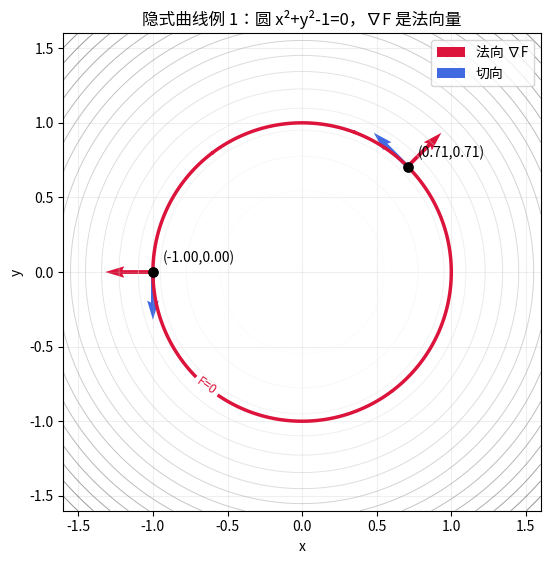

In [5]:
def F_circle(x, y):
    return x**2 + y**2 - 1


def grad_F_circle(x, y):
    return 2 * x, 2 * y


plot_implicit_curve(
    F_circle,
    xlim=(-1.6, 1.6),
    ylim=(-1.6, 1.6),
    grad_F=grad_F_circle,
    points=[(np.sqrt(0.5), np.sqrt(0.5)), (-1.0, 0.0)],
    title="隐式曲线例 1：圆 x²+y²-1=0，∇F 是法向量",
)


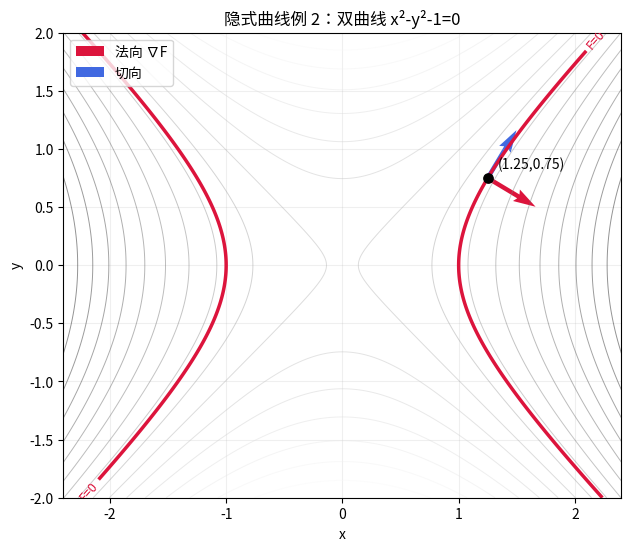

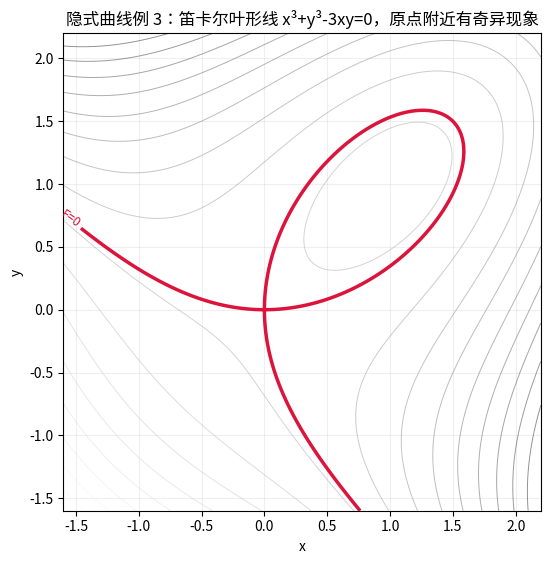

In [6]:
def F_hyperbola(x, y):
    return x**2 - y**2 - 1


def grad_F_hyperbola(x, y):
    return 2 * x, -2 * y


plot_implicit_curve(
    F_hyperbola,
    xlim=(-2.4, 2.4),
    ylim=(-2.0, 2.0),
    grad_F=grad_F_hyperbola,
    points=[(1.25, np.sqrt(1.25**2 - 1))],
    title="隐式曲线例 2：双曲线 x²-y²-1=0",
)


def F_folium(x, y, a=1.0):
    return x**3 + y**3 - 3 * a * x * y


plot_implicit_curve(
    lambda x, y: F_folium(x, y, a=1.0),
    xlim=(-1.6, 2.2),
    ylim=(-1.6, 2.2),
    title="隐式曲线例 3：笛卡尔叶形线 x³+y³-3xy=0，原点附近有奇异现象",
)


## 4. 参数曲面：用两个参数生成三维曲面

参数曲面写作

$$\mathbf r(u,v)=(x(u,v),y(u,v),z(u,v)).$$

两个切向量

$$\mathbf r_u,\quad \mathbf r_v$$

张成切平面；如果 $\mathbf r_u\times \mathbf r_v\neq 0$，叉积方向就是曲面的法向方向。

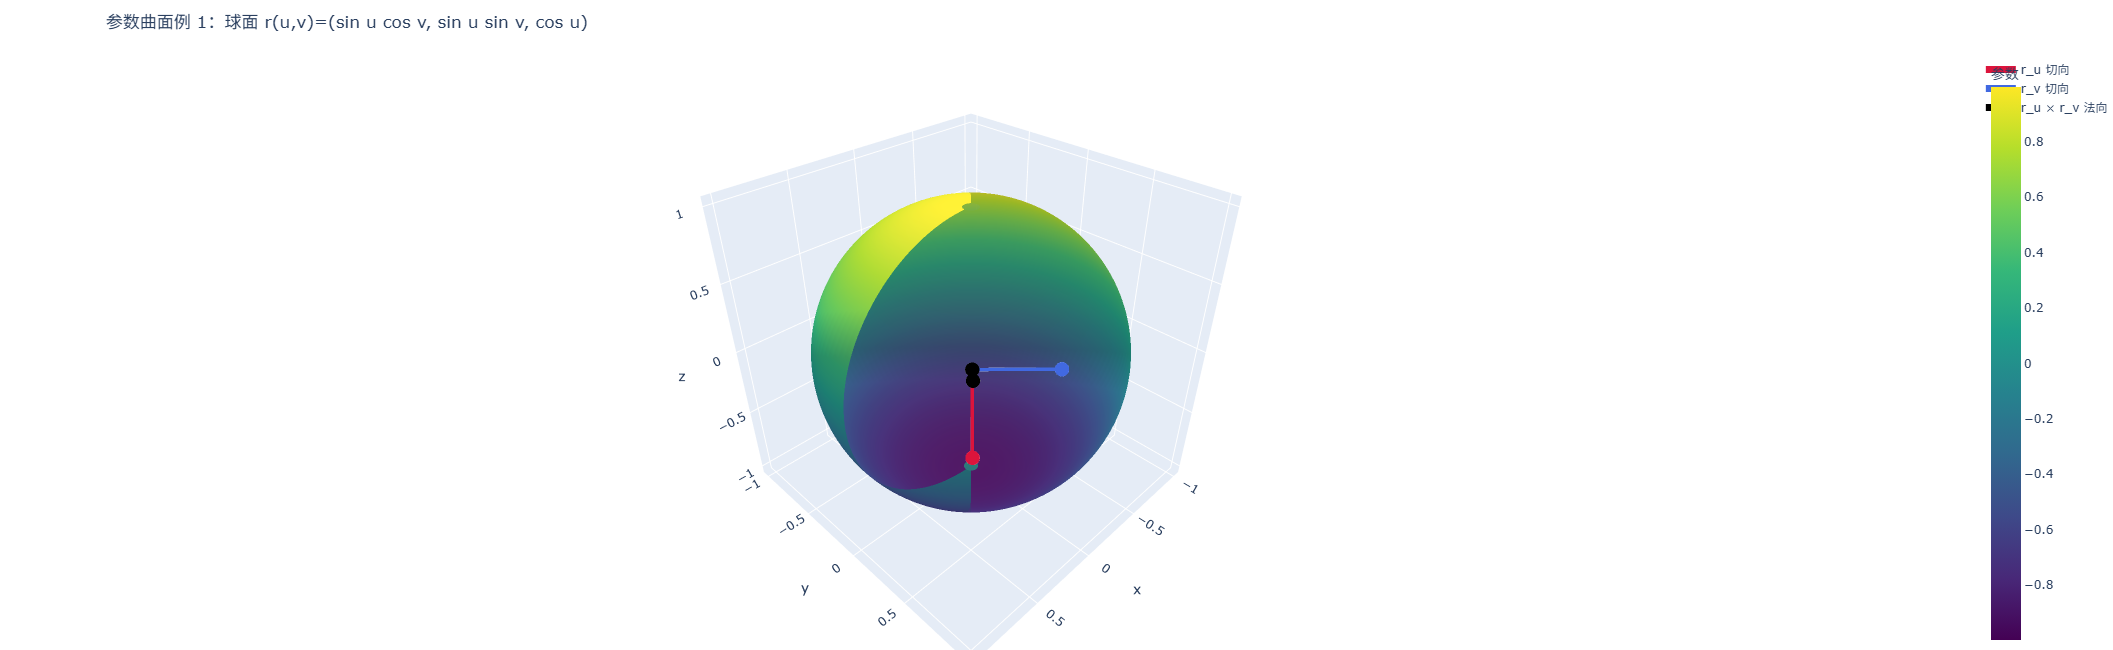

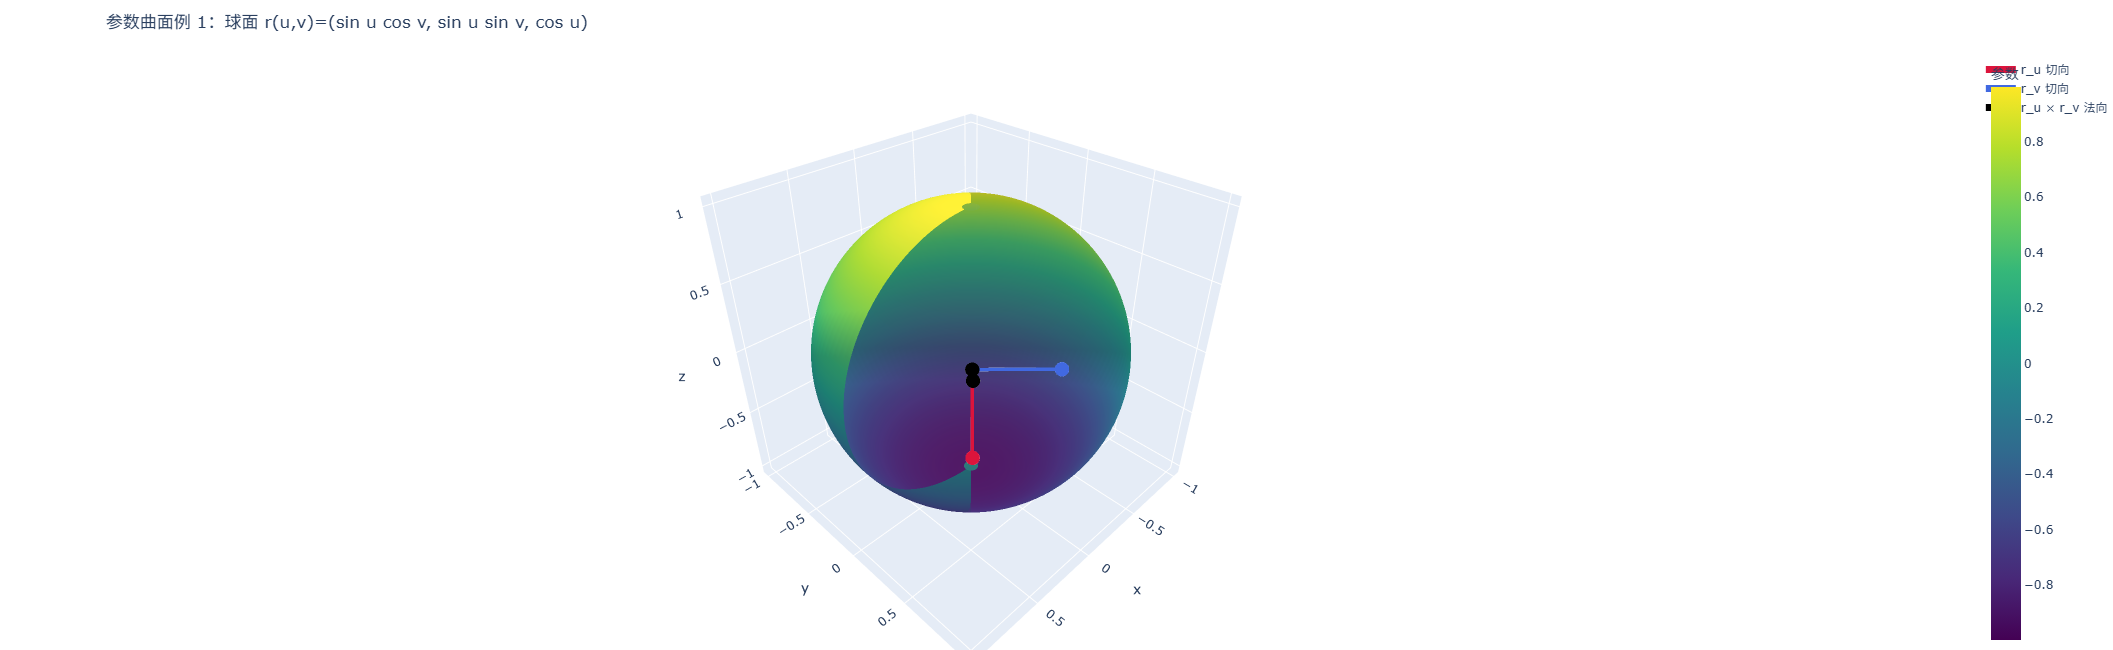

In [7]:
u = np.linspace(0.05, np.pi - 0.05, 90)
v = np.linspace(0, 2 * np.pi, 120)
U, V = np.meshgrid(u, v, indexing="ij")
X_sphere = np.sin(U) * np.cos(V)
Y_sphere = np.sin(U) * np.sin(V)
Z_sphere = np.cos(U)

plot_parametric_surface(
    X_sphere,
    Y_sphere,
    Z_sphere,
    u=u,
    v=v,
    sample_uv=(np.pi / 3, np.pi / 4),
    title="参数曲面例 1：球面 r(u,v)=(sin u cos v, sin u sin v, cos u)",
)


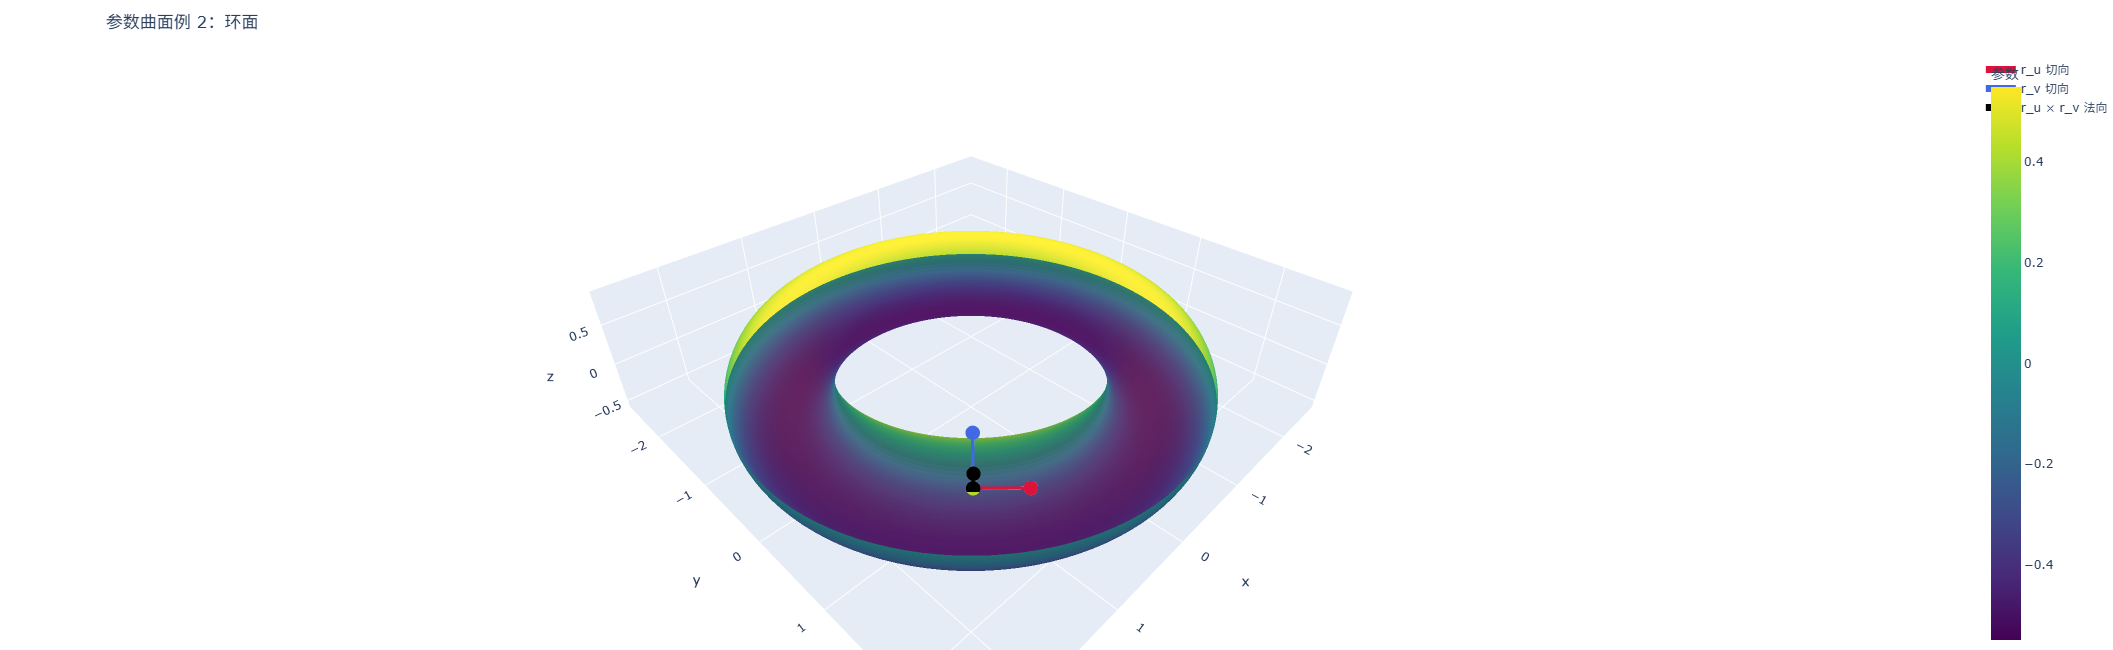

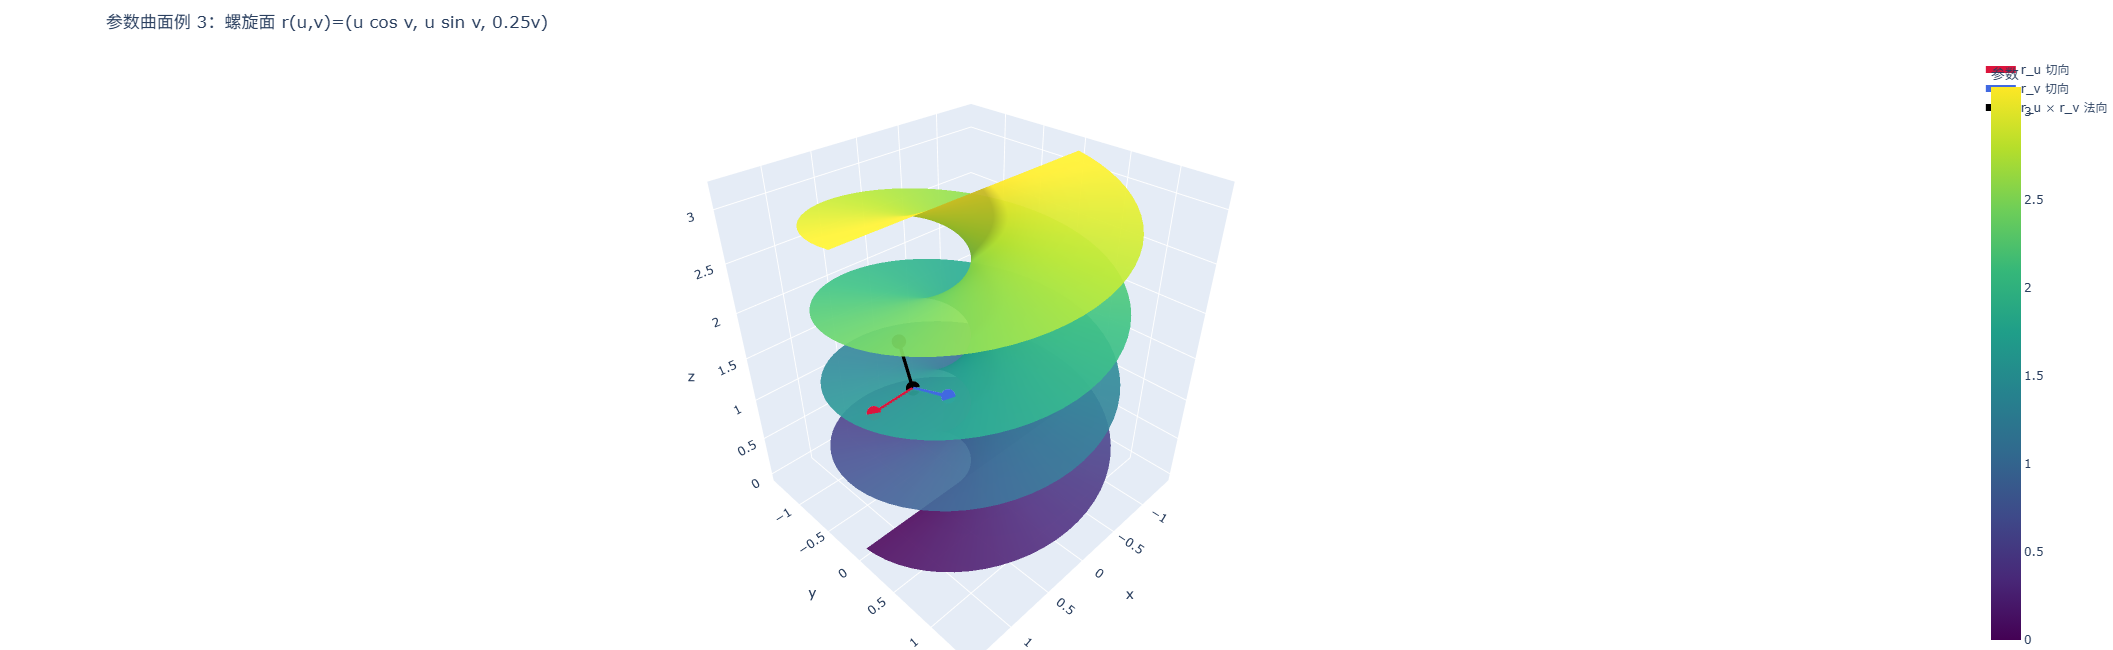

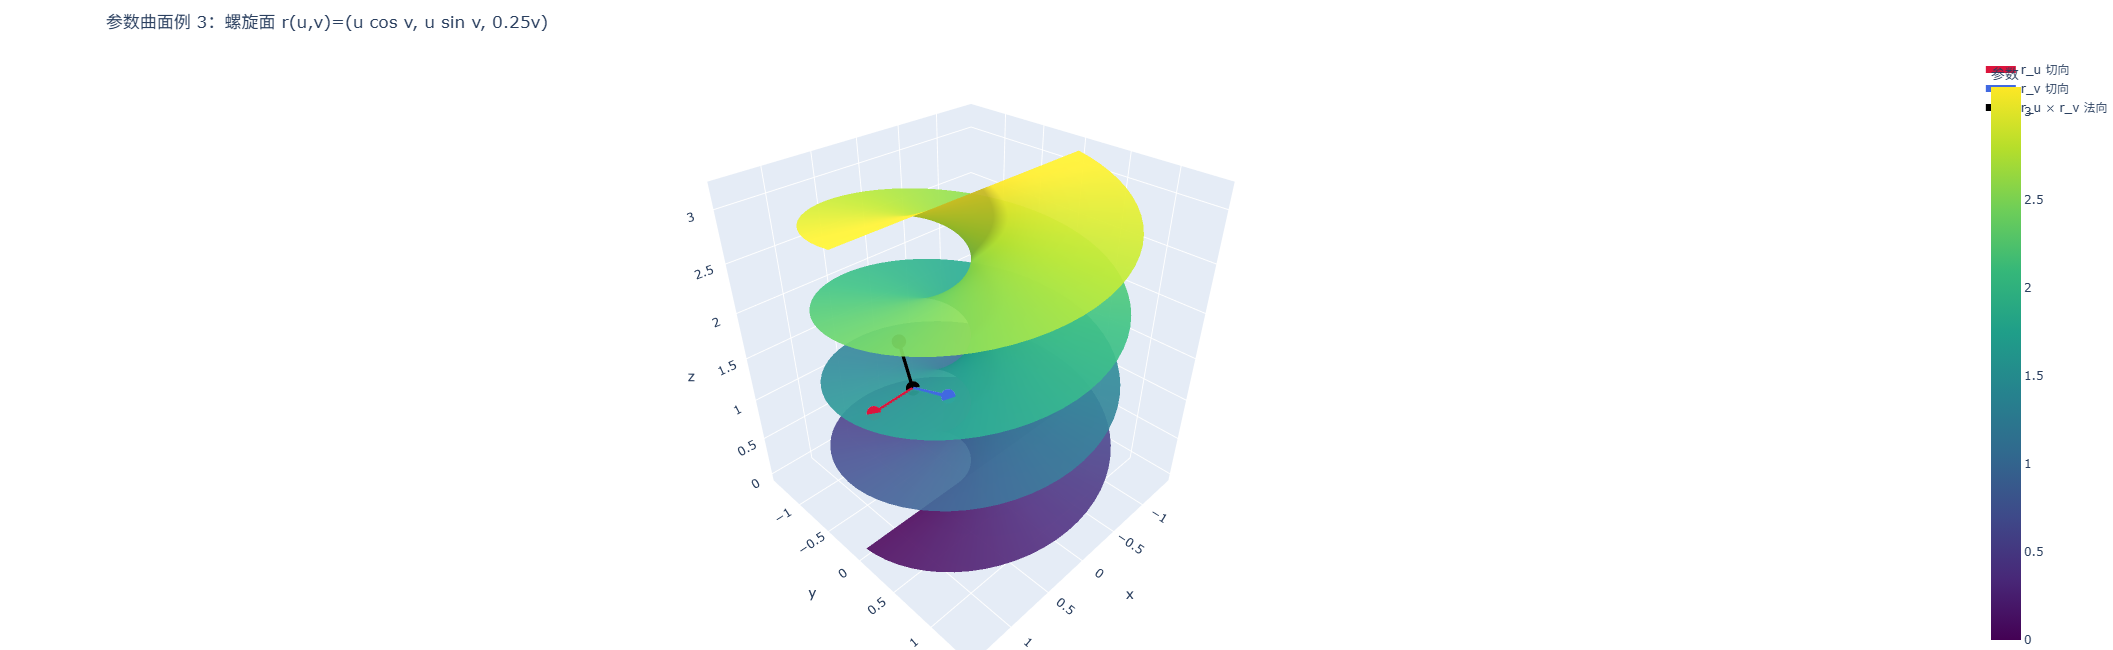

In [8]:
u = np.linspace(0, 2 * np.pi, 120)
v = np.linspace(0, 2 * np.pi, 80)
U, V = np.meshgrid(u, v, indexing="ij")
R, a = 2.0, 0.55
X_torus = (R + a * np.cos(V)) * np.cos(U)
Y_torus = (R + a * np.cos(V)) * np.sin(U)
Z_torus = a * np.sin(V)

plot_parametric_surface(
    X_torus,
    Y_torus,
    Z_torus,
    u=u,
    v=v,
    sample_uv=(np.pi / 4, np.pi / 3),
    title="参数曲面例 2：环面",
)


u = np.linspace(-1.4, 1.4, 70)
v = np.linspace(0, 4 * np.pi, 130)
U, V = np.meshgrid(u, v, indexing="ij")
X_helicoid = U * np.cos(V)
Y_helicoid = U * np.sin(V)
Z_helicoid = 0.25 * V

plot_parametric_surface(
    X_helicoid,
    Y_helicoid,
    Z_helicoid,
    u=u,
    v=v,
    sample_uv=(0.75, 2 * np.pi),
    title="参数曲面例 3：螺旋面 r(u,v)=(u cos v, u sin v, 0.25v)",
)


## 5. 隐式曲面：三维空间中的等值面

隐式曲面写作

$$F(x,y,z)=0.$$

数值绘图时，我们在三维网格上计算 $F$，再用 marching cubes 从体数据里提取等值面。若 $\nabla F\neq 0$，梯度方向是曲面的法向方向。

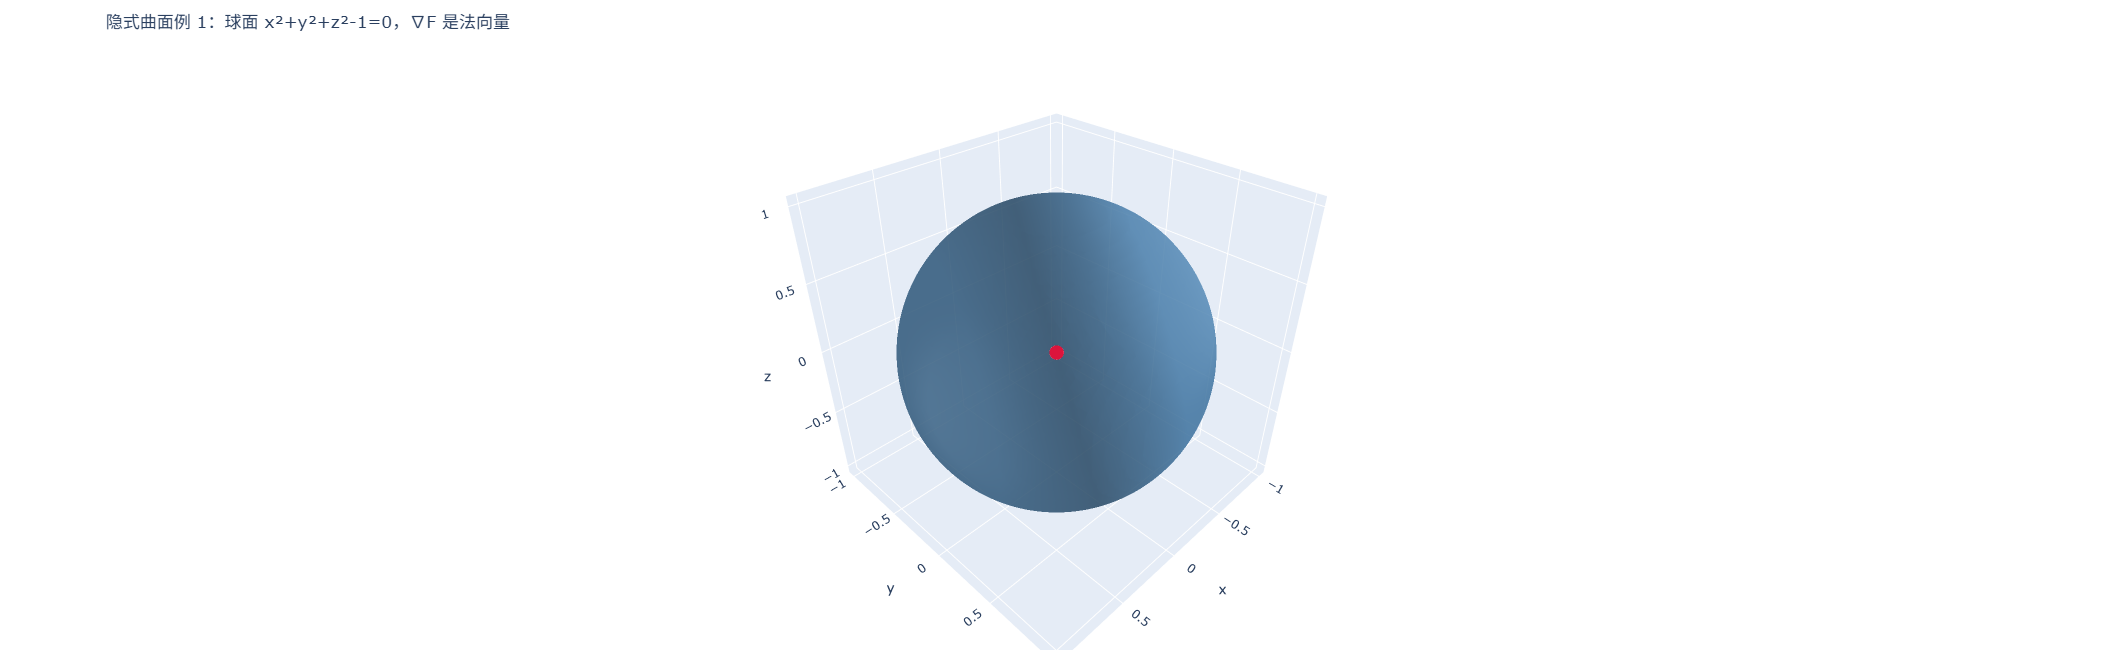

marching_cubes: 9456 个顶点，18908 个三角形。


(Figure({
     'data': [{'color': 'steelblue',
               'flatshading': False,
               'i': {'bdata': ('AgAAAAQAAAAEAAAABQAAAAgAAAAKAA' ... 'AA7SQAAFQkAADuJAAA7iQAAO8kAAA='),
                     'dtype': 'i4'},
               'j': {'bdata': ('AQAAAAMAAAAAAAAAAwAAAAcAAAAJAA' ... 'AASyQAAO4kAABUJAAAViQAAFYkAAA='),
                     'dtype': 'i4'},
               'k': {'bdata': ('AAAAAAAAAAABAAAABAAAAAYAAAAGAA' ... 'AAOCQAAEUkAABWJAAA7yQAAEckAAA='),
                     'dtype': 'i4'},
               'lighting': {'ambient': 0.55, 'diffuse': 0.75, 'specular': 0.25},
               'name': '隐式曲面',
               'opacity': 0.62,
               'type': 'mesh3d',
               'x': {'bdata': ('wRZswVKg7r8+6ZM+6ZPuvz7pkz7pk+' ... 'It2FKg7j/Ygi3YUqDuP9iCLdhSoO4/'),
                     'dtype': 'f8'},
               'y': {'bdata': ('1Cd90id90r/MzMzMLMvSv9QnfdInfd' ... 'RJn/RJzz/QJ33SJ33SP9AnfdInfdI/'),
                     'dtype': 'f8'},
               'z': {'bdata': ('QGzBFmz

In [9]:
def F_sphere(x, y, z):
    return x**2 + y**2 + z**2 - 1


def grad_F_sphere(x, y, z):
    return 2 * x, 2 * y, 2 * z


p = 1 / np.sqrt(3)
plot_implicit_surface(
    F_sphere,
    xlim=(-1.4, 1.4),
    ylim=(-1.4, 1.4),
    zlim=(-1.4, 1.4),
    n=64,
    grad_F=grad_F_sphere,
    normal_point=(p, p, p),
    title="隐式曲面例 1：球面 x²+y²+z²-1=0，∇F 是法向量",
)


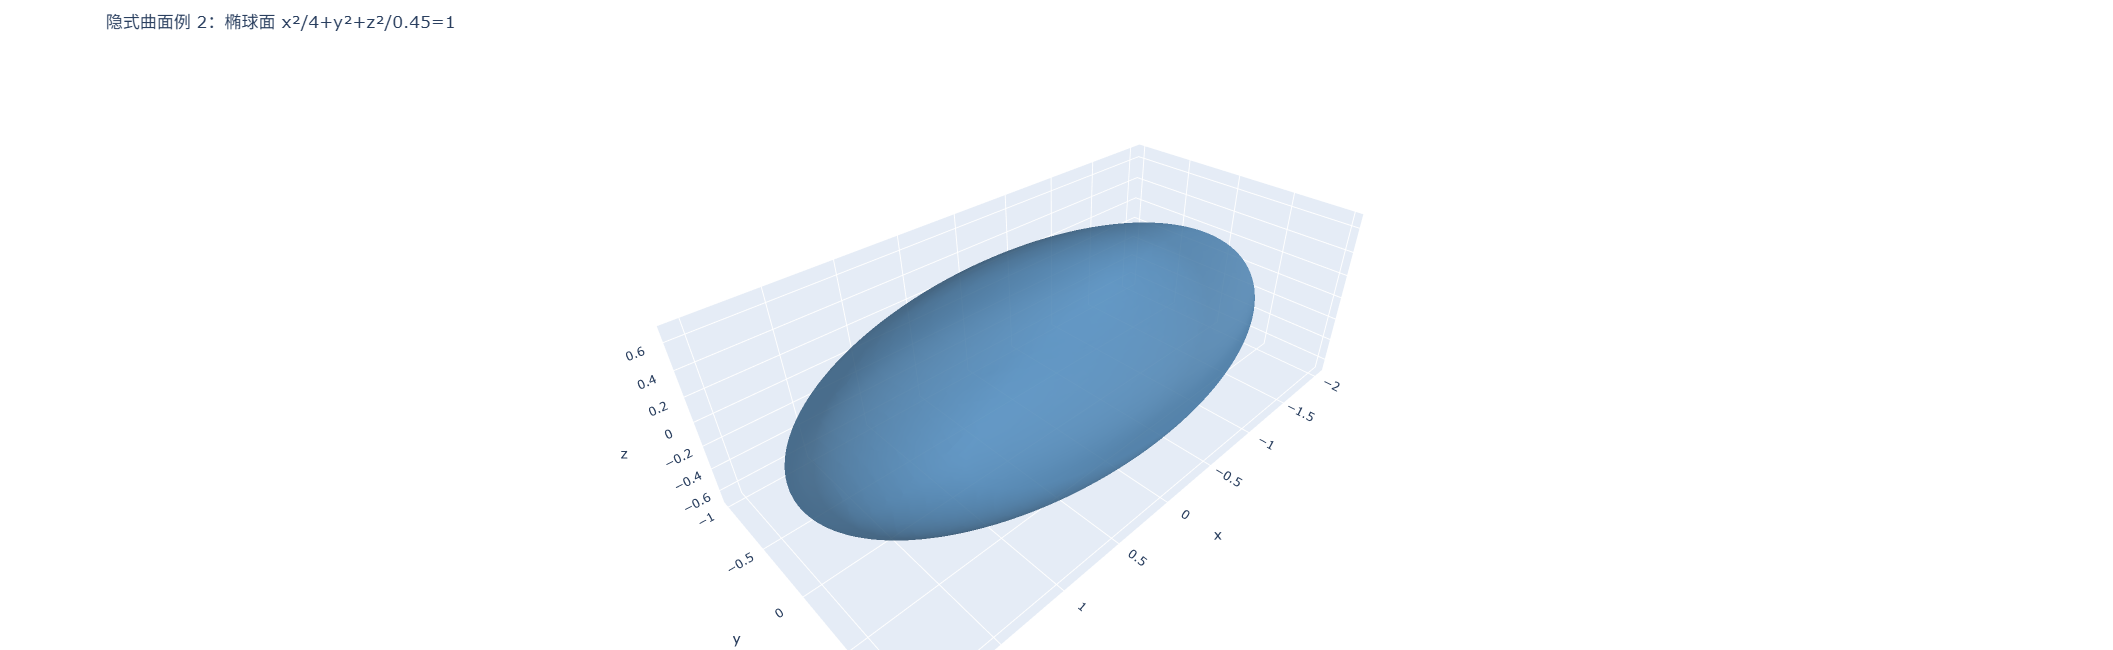

marching_cubes: 10152 个顶点，20300 个三角形。


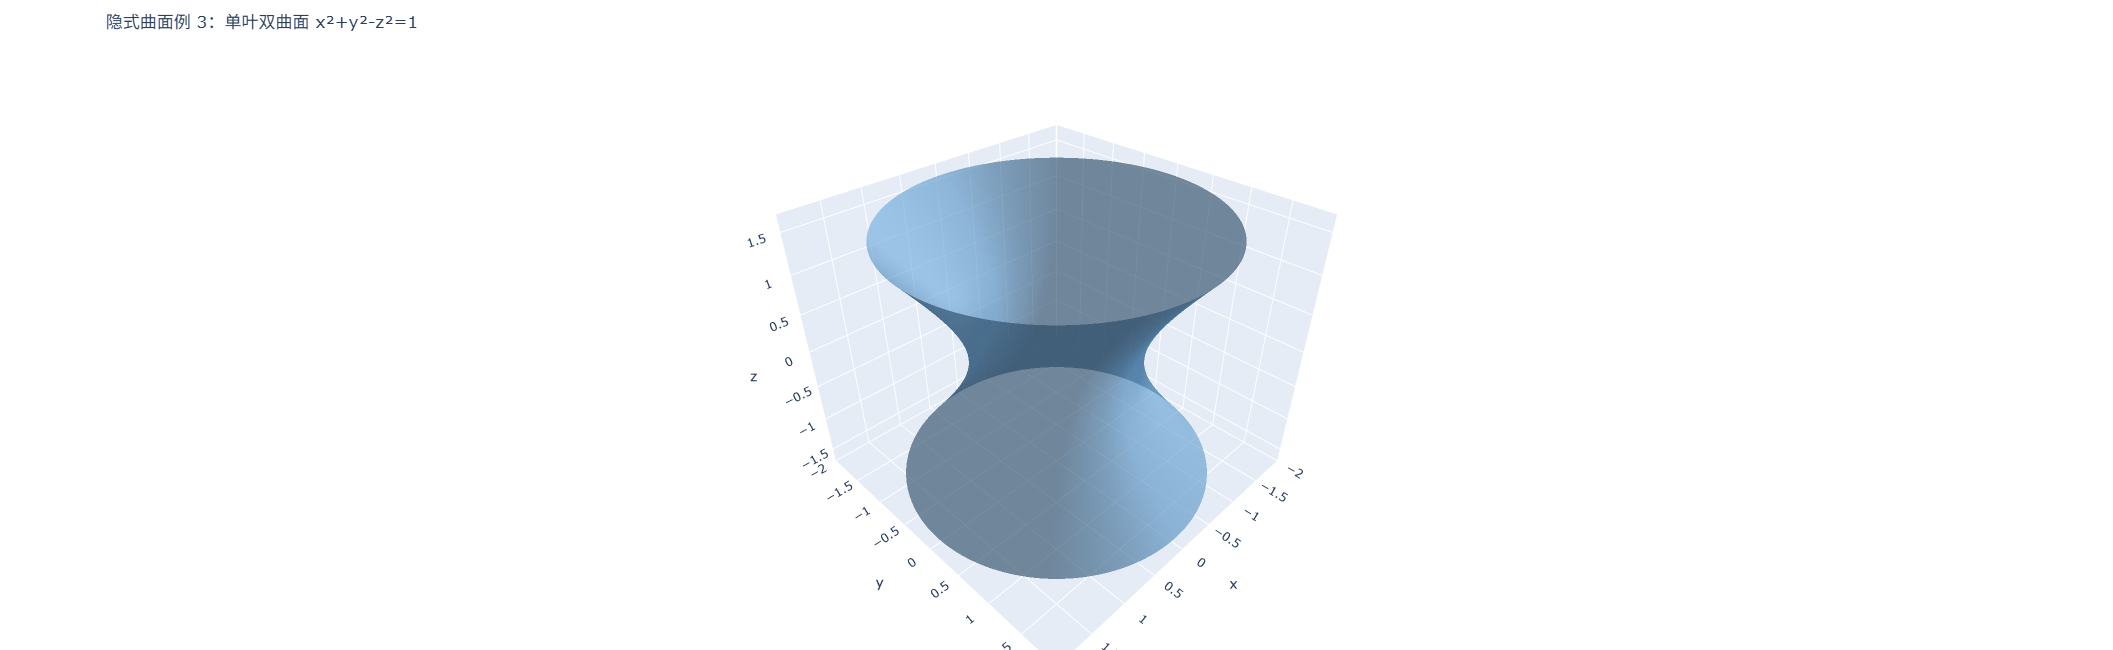

marching_cubes: 14816 个顶点，29152 个三角形。


(Figure({
     'data': [{'color': 'steelblue',
               'flatshading': False,
               'i': {'bdata': ('AgAAAAUAAAABAAAAAQAAAAUAAAAFAA' ... 'DeOQAAwTkAAME5AADeOQAAxjkAAA=='),
                     'dtype': 'i4'},
               'j': {'bdata': ('AQAAAAQAAAACAAAABgAAAAMAAAAIAA' ... 'C7OQAA3zkAAN05AADDOQAA3zkAAA=='),
                     'dtype': 'i4'},
               'k': {'bdata': ('AAAAAAMAAAAGAAAABwAAAAgAAAAJAA' ... 'DcOQAA3TkAAL05AAC/OQAAwTkAAA=='),
                     'dtype': 'i4'},
               'lighting': {'ambient': 0.55, 'diffuse': 0.75, 'specular': 0.25},
               'name': '隐式曲面',
               'opacity': 0.62,
               'type': 'mesh3d',
               'x': {'bdata': ('ft/3fd/3/b8IgiAIfPr9v37f933f9/' ... 'Z9FP4/7vu+73v6/T/u+77ve/r9Pw=='),
                     'dtype': 'f8'},
               'y': {'bdata': ('4LZt23YOzb8gx3Ecx3HMvyDHcRzHcc' ... 'RFUcQ/IMdxHMdxzD8gx3Ecx3HMPw=='),
                     'dtype': 'f8'},
               'z': {'bdata': ('mpmZmZm

In [10]:
def F_ellipsoid(x, y, z):
    return x**2 / 4 + y**2 + z**2 / 0.45 - 1


plot_implicit_surface(
    F_ellipsoid,
    xlim=(-2.4, 2.4),
    ylim=(-1.4, 1.4),
    zlim=(-1.0, 1.0),
    n=64,
    title="隐式曲面例 2：椭球面 x²/4+y²+z²/0.45=1",
)


def F_hyperboloid_one_sheet(x, y, z):
    return x**2 + y**2 - z**2 - 1


plot_implicit_surface(
    F_hyperboloid_one_sheet,
    xlim=(-2.0, 2.0),
    ylim=(-2.0, 2.0),
    zlim=(-1.6, 1.6),
    n=64,
    title="隐式曲面例 3：单叶双曲面 x²+y²-z²=1",
)


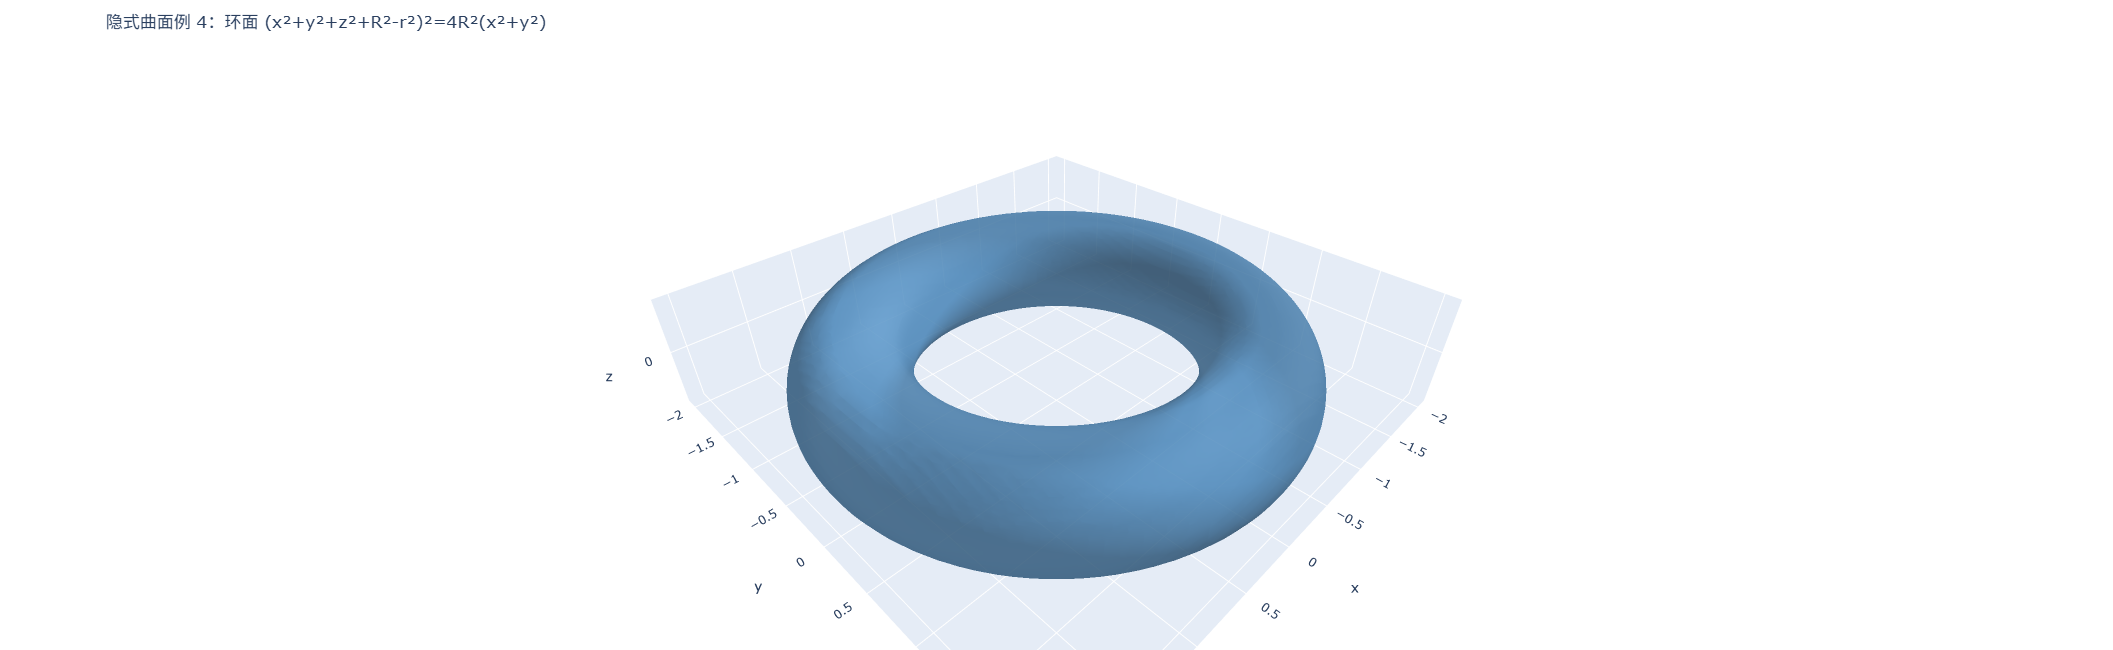

marching_cubes: 18928 个顶点，37856 个三角形。


(Figure({
     'data': [{'color': 'steelblue',
               'flatshading': False,
               'i': {'bdata': ('AgAAAAQAAAAEAAAABgAAAAYAAAAIAA' ... 'AA7UkAAO1JAADuSQAA7kkAAO9JAAA='),
                     'dtype': 'i4'},
               'j': {'bdata': ('AQAAAAMAAAAAAAAABQAAAAMAAAAHAA' ... 'AAG0kAAB1JAAAdSQAAH0kAAB9JAAA='),
                     'dtype': 'i4'},
               'k': {'bdata': ('AAAAAAAAAAABAAAAAwAAAAQAAAAFAA' ... 'AAHUkAAO5JAAAfSQAA70kAAAhJAAA='),
                     'dtype': 'i4'},
               'lighting': {'ambient': 0.55, 'diffuse': 0.75, 'specular': 0.25},
               'name': '隐式曲面',
               'opacity': 0.62,
               'type': 'mesh3d',
               'x': {'bdata': ('BNTe+XpE/7/iTVyA2jv/v+JNXIDaO/' ... 'ck/1T/P3RrWax7T/8/GFVuLXtE/z8='),
                     'dtype': 'f8'},
               'y': {'bdata': ('kNJ0isDH2b/EBai9U3Dav5DSdIrAx9' ... 'SKwMfZP5jSdIrAx9k/mNJ0isDH2T8='),
                     'dtype': 'f8'},
               'z': {'bdata': ('OAcSrbA

In [11]:
def F_torus(x, y, z, R=1.55, r=0.45):
    return (x**2 + y**2 + z**2 + R**2 - r**2) ** 2 - 4 * R**2 * (x**2 + y**2)


plot_implicit_surface(
    lambda x, y, z: F_torus(x, y, z, R=1.55, r=0.45),
    xlim=(-2.2, 2.2),
    ylim=(-2.2, 2.2),
    zlim=(-0.9, 0.9),
    n=72,
    title="隐式曲面例 4：环面 (x²+y²+z²+R²-r²)²=4R²(x²+y²)",
)


## 6. 参数形式与隐式形式的对比

同一个几何对象常常既可以参数表示，也可以隐式表示。

- 参数形式：容易生成点，适合动画、轨迹、曲面网格。
- 隐式形式：容易判断点在曲面内外，适合水平集、约束方程和法向量。

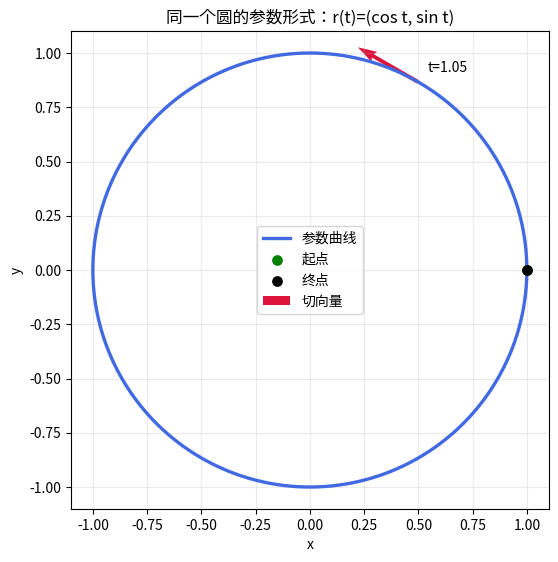

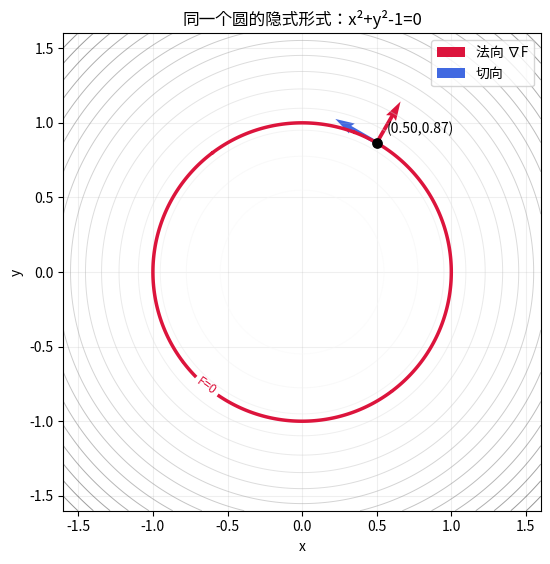

In [12]:
t = np.linspace(0, 2 * np.pi, 600)
plot_parametric_curve(
    np.cos(t),
    np.sin(t),
    t,
    tangent_at=[np.pi / 3],
    title="同一个圆的参数形式：r(t)=(cos t, sin t)",
)

plot_implicit_curve(
    lambda x, y: x**2 + y**2 - 1,
    xlim=(-1.6, 1.6),
    ylim=(-1.6, 1.6),
    points=[(0.5, np.sqrt(0.75))],
    title="同一个圆的隐式形式：x²+y²-1=0",
)


## 7. 交互实验

交互控件适合展示参数变化如何改变曲线或曲面。

In [13]:
def explore_circle_level(c=1.0):
    plot_implicit_curve(
        lambda x, y: x**2 + y**2,
        xlim=(-2.2, 2.2),
        ylim=(-2.2, 2.2),
        level=c,
        n=301,
        title=f"交互实验 1：水平集 x²+y²={c:.2f}",
    )


interact(
    explore_circle_level,
    c=FloatSlider(value=1.0, min=0.1, max=4.0, step=0.1, description="c"),
);


interactive(children=(FloatSlider(value=1.0, description='c', max=4.0, min=0.1), Output()), _dom_classes=('wid…

In [14]:
def explore_implicit_torus(R=1.55, r=0.45):
    plot_implicit_surface(
        lambda x, y, z: F_torus(x, y, z, R=R, r=r),
        xlim=(-2.4, 2.4),
        ylim=(-2.4, 2.4),
        zlim=(-1.2, 1.2),
        n=48,
        title=f"交互实验 2：隐式环面 R={R:.2f}, r={r:.2f}",
    )


interact(
    explore_implicit_torus,
    R=FloatSlider(value=1.55, min=1.0, max=2.0, step=0.05, description="R"),
    r=FloatSlider(value=0.45, min=0.2, max=0.75, step=0.05, description="r"),
);


interactive(children=(FloatSlider(value=1.55, description='R', max=2.0, min=1.0, step=0.05), FloatSlider(value…

## 8. 小练习

1. 把参数曲线改成 $r(t)=(\cos(3t),\sin(2t))$，观察李萨如图形。
2. 修改隐式曲线为 $x^4+y^4=1$，比较它和圆的差异。
3. 把参数曲面改成双曲抛物面 $r(u,v)=(u,v,u^2-v^2)$，观察切向量和法向量。
4. 修改隐式曲面为 $x^2+y^2-z^2=c$，观察 $c$ 正负变化时的形状。

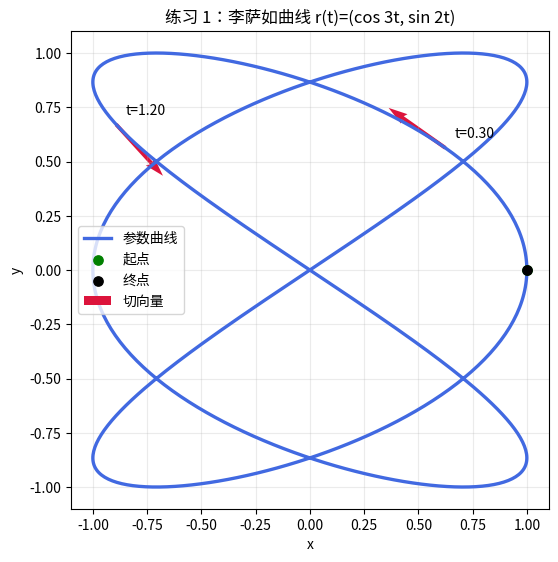

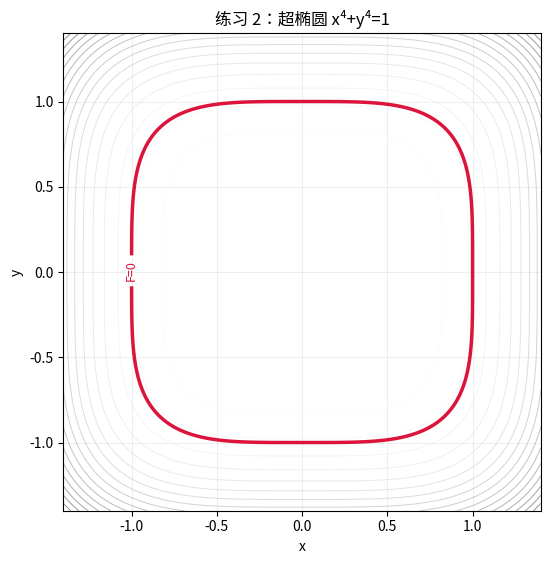

In [15]:
t = np.linspace(0, 2 * np.pi, 800)
plot_parametric_curve(
    np.cos(3 * t),
    np.sin(2 * t),
    t,
    tangent_at=[0.3, 1.2],
    title="练习 1：李萨如曲线 r(t)=(cos 3t, sin 2t)",
)

plot_implicit_curve(
    lambda x, y: x**4 + y**4 - 1,
    xlim=(-1.4, 1.4),
    ylim=(-1.4, 1.4),
    title="练习 2：超椭圆 x⁴+y⁴=1",
)

u = np.linspace(-1.5, 1.5, 80)
v = np.linspace(-1.5, 1.5, 80)
U, V = np.meshgrid(u, v, indexing="ij")
plot_parametric_surface(
    U,
    V,
    U**2 - V**2,
    u=u,
    v=v,
    sample_uv=(0.8, 0.6),
    title="练习 3：双曲抛物面 r(u,v)=(u,v,u²-v²)",
)
